# Visualize data — chạy trực tiếp trong VS Code
Chọn **Select Kernel → Python Environments → .venv**, rồi **Run All**. Biểu đồ xuất ngay dưới từng ô code.

Mặc định dùng số tham chiếu trong `docs/CHIA_DU_LIEU.md`, không cần NPZ hay GPU.
Đổi `SOURCE = "actual"` khi đã có dữ liệu xử lý. Không tự chạy huấn luyện hoặc inference bằng checkpoint.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src/data_splits.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Hãy mở notebook trong thư mục dự án UWB_RADAR.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data_splits import DEV_USERS, TEST_USERS, split_plan

SOURCE = "documented"  # "documented" hoặc "actual"
DATA_DIR = ROOT / "data/processed"
CORR = 0.9
USER, SESSION, BIN = "A", 0, 24  # Chỉ dùng khi SOURCE = "actual"
SAVE_PNG = False  # True để lưu thêm ảnh; luôn hiển thị trực tiếp trong notebook

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False})
COLORS = {"train": "#087f8c", "validation": "#e7aa35", "test": "#9665b5"}
plan = split_plan()

def show_figure(fig, name):
    if SAVE_PNG:
        out = ROOT / "reports/data_visualization" / SOURCE
        out.mkdir(parents=True, exist_ok=True)
        fig.savefig(out / (name + ".png"), dpi=180, bbox_inches="tight")
    plt.show()


## 1. Nạp số liệu
Chế độ tham chiếu ghi rõ nguồn; chế độ actual đọc header NPZ để đếm mà không nạp mảng radar/cửa sổ lớn. Thiếu file sẽ báo lỗi, không tự chuyển sang số tham chiếu.


In [2]:
import zipfile

def npz_shape(path, key):
    with zipfile.ZipFile(path) as archive, archive.open(key + ".npy") as stream:
        version = np.lib.format.read_magic(stream)
        if version == (1, 0):
            shape, _, _ = np.lib.format.read_array_header_1_0(stream)
        elif version == (2, 0):
            shape, _, _ = np.lib.format.read_array_header_2_0(stream)
        else:
            raise ValueError(f"NPY version {version} chưa được hỗ trợ: {path}")
    return shape

if SOURCE == "documented":
    if CORR != 0.9:
        raise ValueError("Số tham chiếu chỉ có cho CORR = 0.9.")
    sessions = dict(zip("ABCDEFGHIJKL", [224,156,211,206,126,102,134,138,145,120,148,116]))
    windows = dict(zip(DEV_USERS, [42640,39104,47996,53300,25792,9256,50804,23816]))
    origin = "THAM CHIẾU: docs/CHIA_DU_LIEU.md — chưa đo dữ liệu thực"
elif SOURCE == "actual":
    sessions, windows = {}, {}
    for user in sorted(DEV_USERS + TEST_USERS):
        path = DATA_DIR / "by_user" / (user + ".npz")
        shape = npz_shape(path, "uwb")
        if len(shape) != 3 or shape[0] <= 0 or shape[1:] != (1500, 120):
            raise ValueError(f"Shape radar không hợp lệ: {path}: {shape}")
        n = shape[0]
        if npz_shape(path, "gt") != (n, 1500) or npz_shape(path, "files") != (n,):
            raise ValueError(f"GT/files không khớp radar: {path}")
        sessions[user] = n
    for user in DEV_USERS:
        path = DATA_DIR / "windows/dev_cv" / f"{user}_corr{CORR}_h200_f25.npz"
        x, y = npz_shape(path, "X"), npz_shape(path, "y")
        if len(x) not in (2, 3) or x[0] <= 0:
            raise ValueError(f"Shape X không hợp lệ: {path}: {x}")
        n = x[0]
        if x not in ((n, 200), (n, 200, 1)) or y not in ((n, 25), (n, 25, 1)):
            raise ValueError(f"Shape X/y không hợp lệ: {path}: {x}, {y}")
        windows[user] = n
    origin = "THỰC TẾ: đếm từ header các file NPZ"
else:
    raise ValueError('SOURCE phải là "documented" hoặc "actual".')

print(origin)
print(f"Tổng: {sum(sessions.values()):,} session")
print(f"Development ABCDEFKL: {sum(sessions[u] for u in DEV_USERS):,} session")
print(f"Test GHIJ: {sum(sessions[u] for u in TEST_USERS):,} session")
print(f"Cửa sổ train trong pool: {sum(windows.values()):,}")


THAM CHIẾU: docs/CHIA_DU_LIEU.md — chưa đo dữ liệu thực
Tổng: 1,826 session
Development ABCDEFKL: 1,289 session
Test GHIJ: 537 session
Cửa sổ train trong pool: 292,708


## 2. Phân bố session và cửa sổ train
Cột session thể hiện cả 12 người. Cửa sổ đã lọc bằng ground truth chỉ được tính cho pool phát triển.


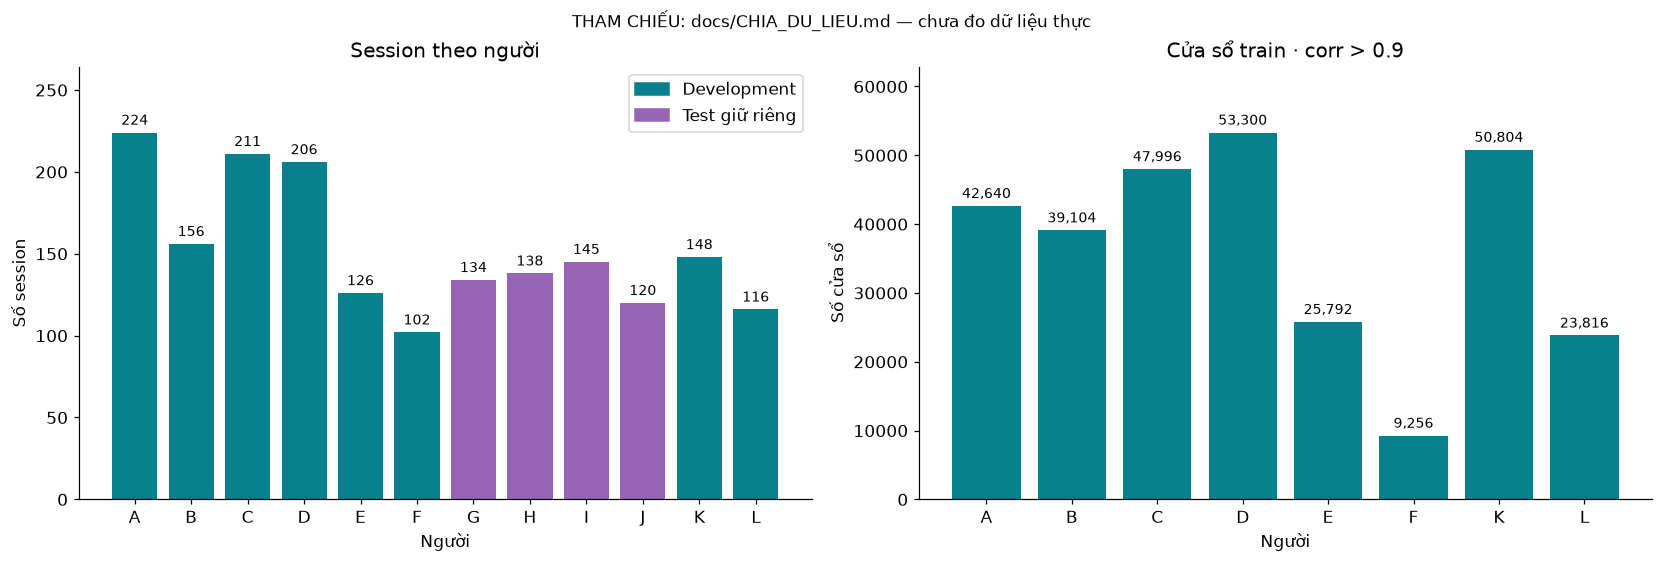

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
users = sorted(sessions)
bars = axes[0].bar(users, [sessions[u] for u in users],
                   color=[COLORS["test"] if u in TEST_USERS else COLORS["train"] for u in users])
axes[0].bar_label(bars, padding=3, fontsize=9)
axes[0].set(title="Session theo người", xlabel="Người", ylabel="Số session",
            ylim=(0, max(sessions.values()) * 1.18))
axes[0].legend(handles=[Patch(color=COLORS["train"], label="Development"),
                        Patch(color=COLORS["test"], label="Test giữ riêng")])
bars = axes[1].bar(DEV_USERS, [windows[u] for u in DEV_USERS], color=COLORS["train"])
axes[1].bar_label(bars, labels=[f"{windows[u]:,}" for u in DEV_USERS], padding=3, fontsize=9)
axes[1].set(title=f"Cửa sổ train · corr > {CORR}", xlabel="Người", ylabel="Số cửa sổ",
            ylim=(0, max(windows.values()) * 1.18))
fig.suptitle(origin, fontsize=11)
show_figure(fig, "01_distribution")


## 3. Người nào thuộc train / validation / test?
Bốn fold giữ nguyên AB / CE / DF / KL. Hàng cuối là giai đoạn train lại đủ tám người.
Ô tím ở các fold nghĩa là giữ riêng GHIJ, không đánh giá test trong CV.


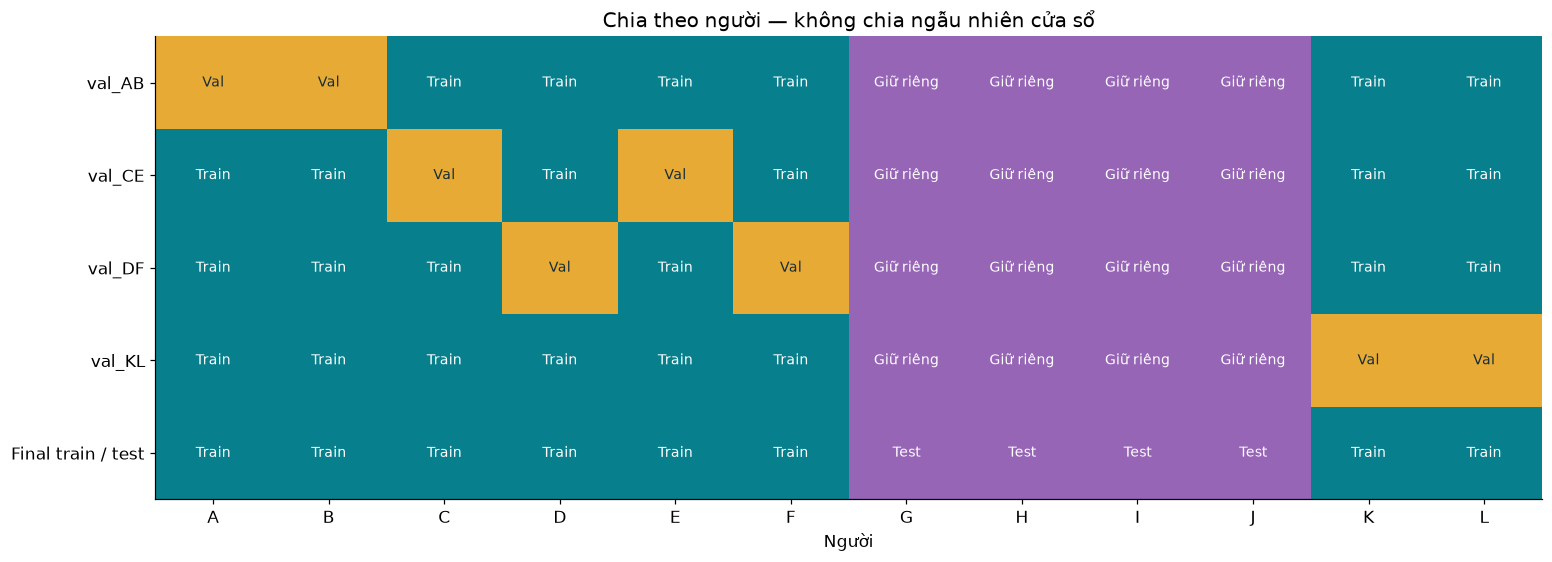

In [4]:
users = sorted(DEV_USERS + TEST_USERS)
matrix = []
for fold in plan["folds"]:
    tr, val = set(fold["train"]), set(fold["validation"])
    assert not tr & val and tr | val == set(DEV_USERS)
    assert not (tr | val) & set(TEST_USERS)
    matrix.append([2 if u in TEST_USERS else 1 if u in val else 0 for u in users])
assert sorted(u for f in plan["folds"] for u in f["validation"]) == sorted(DEV_USERS)
matrix.append([2 if u in TEST_USERS else 0 for u in users])
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
ax.imshow(matrix, cmap=ListedColormap([COLORS["train"], COLORS["validation"], COLORS["test"]]),
          vmin=0, vmax=2, aspect="auto")
ax.set_xticks(range(len(users)), users)
ax.set_yticks(range(5), [f["name"] for f in plan["folds"]] + ["Final train / test"])
for row, values in enumerate(matrix):
    for col, role in enumerate(values):
        label = ["Train", "Val", "Giữ riêng" if row < 4 else "Test"][role]
        ax.text(col, row, label, ha="center", va="center",
                color="#172d35" if role == 1 else "white", fontsize=9)
ax.set(title="Chia theo người — không chia ngẫu nhiên cửa sổ", xlabel="Người")
show_figure(fig, "02_split_matrix")


## 4. Số lượng train và validation trong từng fold
Validation dùng session nguyên vẹn, không dùng cửa sổ đã lọc corr với GT. Chênh lệch cửa sổ train tính bằng (max − min) / min.


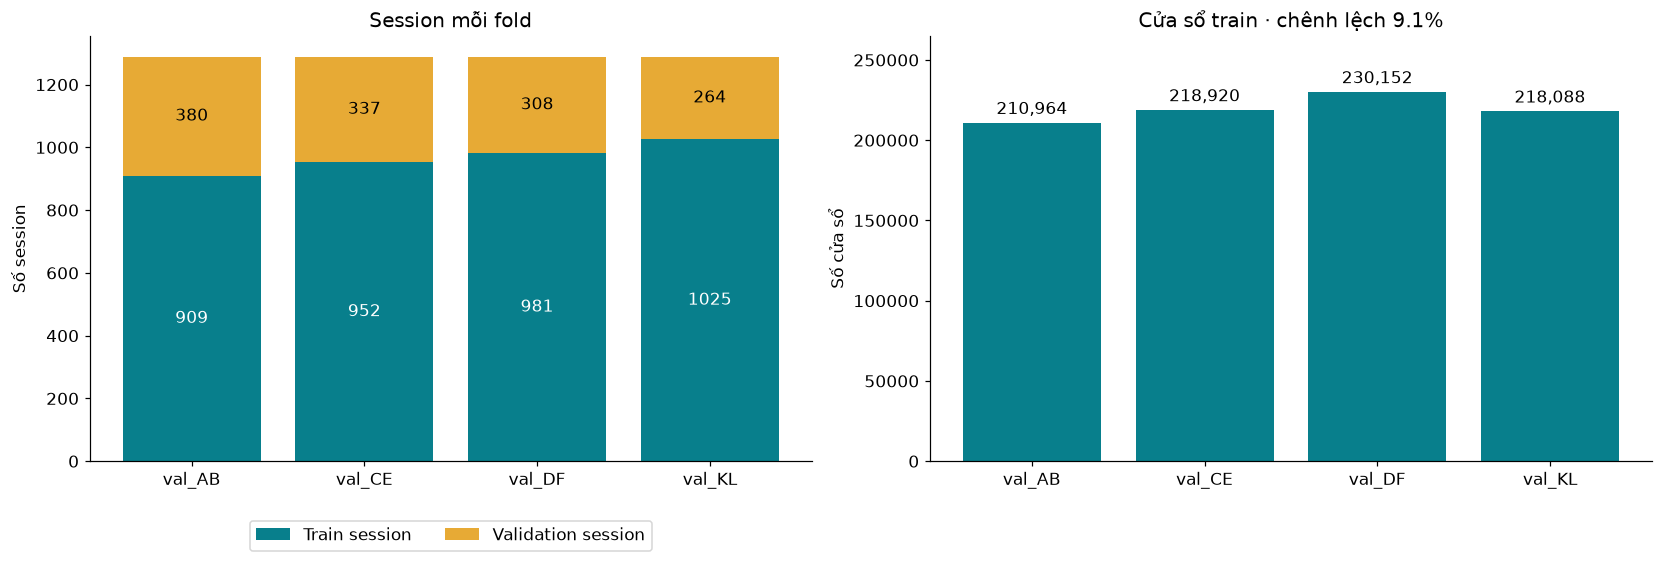

Fold       Train           Validation    Session train  Session val
val_AB     C D E F K L     A B                     909          380
val_CE     A B D F K L     C E                     952          337
val_DF     A B C E K L     D F                     981          308
val_KL     A B C D E F     K L                   1,025          264


In [5]:
names = [f["name"] for f in plan["folds"]]
train_n = [sum(sessions[u] for u in f["train"]) for f in plan["folds"]]
val_n = [sum(sessions[u] for u in f["validation"]) for f in plan["folds"]]
window_n = [sum(windows[u] for u in f["train"]) for f in plan["folds"]]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
b1 = axes[0].bar(names, train_n, color=COLORS["train"], label="Train session")
b2 = axes[0].bar(names, val_n, bottom=train_n, color=COLORS["validation"], label="Validation session")
axes[0].bar_label(b1, label_type="center", color="white")
axes[0].bar_label(b2, label_type="center")
axes[0].set(title="Session mỗi fold", ylabel="Số session")
axes[0].legend(loc="upper center", bbox_to_anchor=(.5, -.12), ncol=2)
b3 = axes[1].bar(names, window_n, color=COLORS["train"])
axes[1].bar_label(b3, labels=[f"{n:,}" for n in window_n], padding=3)
spread = 100 * (max(window_n) - min(window_n)) / min(window_n)
axes[1].set(title=f"Cửa sổ train · chênh lệch {spread:.1f}%",
            ylabel="Số cửa sổ", ylim=(0, max(window_n) * 1.15))
show_figure(fig, "03_fold_sizes")
print(f"{'Fold':<10} {'Train':<15} {'Validation':<12} {'Session train':>14} {'Session val':>12}")
for f, nt, nv in zip(plan["folds"], train_n, val_n):
    print(f'{f["name"]:<10} {" ".join(f["train"]):<15} {" ".join(f["validation"]):<12} {nt:>14,} {nv:>12,}')


## 5. Luồng validation và inference
Điểm CV: Pearson từng session → trung bình mỗi người → trung bình 2 người/fold → trung bình 4 fold.
Chạy cùng seed 0, 1, 2 để so cấu hình. Inference là thao tác chạy model, không phải tập chia thứ tư.


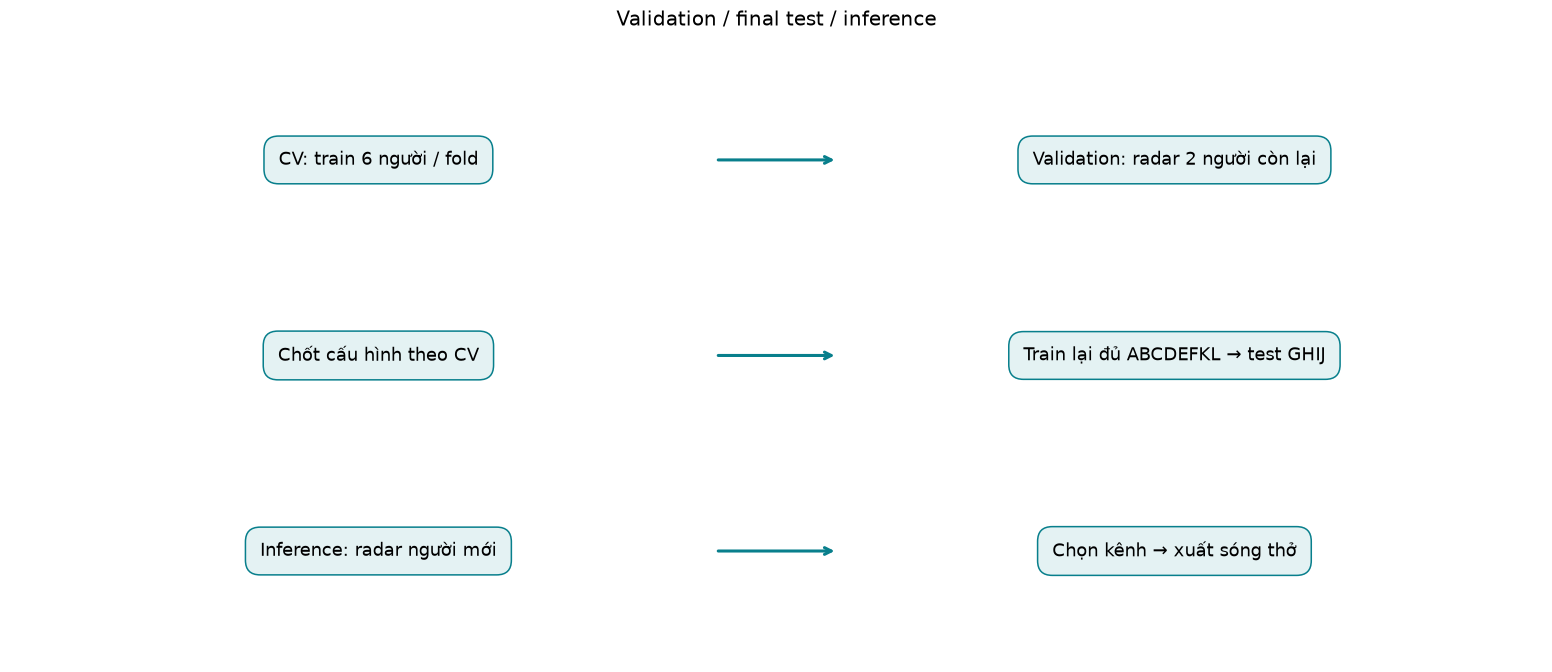

Chọn kênh chỉ nhận UWB, không nhận ground truth.
GT chỉ dùng chấm Pearson sau khi đã chọn kênh.
200 mẫu lịch sử → dự báo 25 mẫu; xử lý toàn session 1500 mẫu, chưa phải streaming.
Sóng được chọn chưa phải nhịp thở BPM. Ô này minh họa quy trình, không chạy model.


In [6]:
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)
ax.set(xlim=(0, 1), ylim=(0, 1))
ax.axis("off")
steps = [
    ("CV: train 6 người / fold", "Validation: radar 2 người còn lại"),
    ("Chốt cấu hình theo CV", "Train lại đủ ABCDEFKL → test GHIJ"),
    ("Inference: radar người mới", "Chọn kênh → xuất sóng thở"),
]
for y, (left, right) in zip([.82, .50, .18], steps):
    for x, text in [(.24, left), (.76, right)]:
        ax.text(x, y, text, ha="center", va="center", fontsize=12,
                bbox=dict(boxstyle="round,pad=.8", facecolor="#e4f2f3", edgecolor=COLORS["train"]))
    ax.annotate("", xy=(.54, y), xytext=(.46, y),
                arrowprops=dict(arrowstyle="->", color=COLORS["train"], lw=2))
ax.set_title("Validation / final test / inference", pad=16)
show_figure(fig, "04_pipeline")
print("Chọn kênh chỉ nhận UWB, không nhận ground truth.")
print("GT chỉ dùng chấm Pearson sau khi đã chọn kênh.")
print("200 mẫu lịch sử → dự báo 25 mẫu; xử lý toàn session 1500 mẫu, chưa phải streaming.")
print("Sóng được chọn chưa phải nhịp thở BPM. Ô này minh họa quy trình, không chạy model.")


## 6. Xem tín hiệu radar thực (tùy chọn)
Chỉ chạy khi `SOURCE = "actual"`. Khi dùng số tham chiếu, ô này bỏ qua để **Run All** vẫn hoàn tất.
Bin được chọn thủ công để minh họa; không phải kết quả inference. Dữ liệu NPZ nén có thể cần vài trăm MB RAM khi đọc một người.


In [7]:
if SOURCE != "actual":
    print('Chưa vẽ tín hiệu: đổi SOURCE = "actual" và Run All khi đã có NPZ.')
else:
    if USER not in DEV_USERS:
        raise ValueError("Chỉ khám phá ABCDEFKL trước khi chốt cấu hình.")
    if not 0 <= SESSION < sessions[USER] or not 0 <= BIN < 120:
        raise ValueError("SESSION ngoài số buổi ghi hoặc BIN ngoài khoảng 0..119.")
    with np.load(DATA_DIR / "by_user" / f"{USER}.npz", allow_pickle=False) as data:
        radar = data["uwb"][SESSION].copy()
        gt = data["gt"][SESSION].copy()
        session_name = str(data["files"][SESSION])
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), constrained_layout=True)
    heat = axes[0].imshow(np.abs(radar).T, origin="lower", aspect="auto")
    axes[0].set(title=session_name, ylabel="Range bin")
    fig.colorbar(heat, ax=axes[0], label="Biên độ radar")
    axes[1].plot(np.abs(radar[:, BIN]), label=f"abs · bin {BIN}")
    axes[1].set(ylabel="Biên độ")
    axes[1].legend()
    axes[2].plot(gt, label="Ground truth")
    axes[2].axvspan(0, 199, alpha=.2, color=COLORS["train"], label="History: 200 mẫu")
    axes[2].axvspan(200, 224, alpha=.3, color=COLORS["validation"], label="Future: 25 mẫu")
    axes[2].set(xlabel="Chỉ số mẫu", ylabel="GT chuẩn hóa")
    axes[2].legend()
    show_figure(fig, f"05_session_{USER}_{SESSION}")


Chưa vẽ tín hiệu: đổi SOURCE = "actual" và Run All khi đã có NPZ.
